In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler

import arviz as az

/home/amaan/micromamba/envs/stan/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='unicode_escape')
data = pd.read_csv('data/speed_dating_data.csv', sep=',', encoding='ISO-8859-1')
data.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='attr', ylabel='Count'>

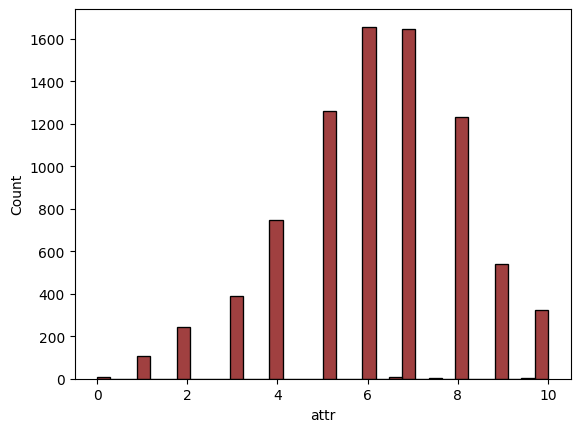

In [4]:
sns.histplot(data.attr, color='maroon', alpha=0.75)

In [5]:
data = data[['attr', 'sinc', 'shar', 'dec']].dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 8377
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   attr    7267 non-null   float64
 1   sinc    7267 non-null   float64
 2   shar    7267 non-null   float64
 3   dec     7267 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 283.9 KB


## Handy Function to Plot Predictions per Subject

In [6]:
scaler = StandardScaler()
cols = ['attr', 'sinc', 'shar']
data[cols] = scaler.fit_transform(data[cols])

<Axes: xlabel='dec', ylabel='Count'>

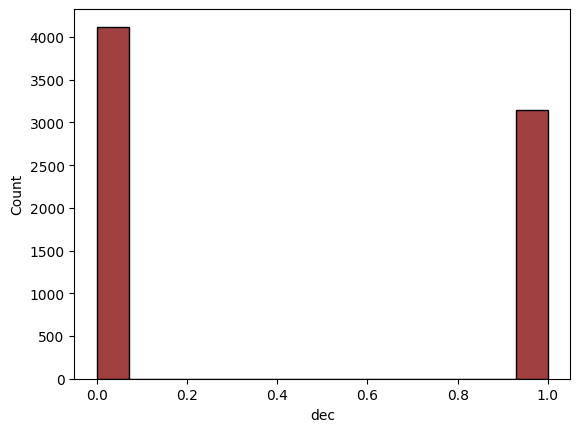

In [7]:
sns.histplot(data.dec, color='maroon', alpha=0.75)

In [8]:
# correlation
data[["attr", "sinc", "shar", "dec"]].corr()

,attr,sinc,shar,dec
attr,1.000000,0.401670,0.480331,0.485902
sinc,0.401670,1.000000,0.398321,0.208105
shar,0.480331,0.398321,1.000000,0.401667
dec,0.485902,0.208105,0.401667,1.000000


In [9]:
from cmdstanpy import install_cmdstan
install_cmdstan()

CmdStan install directory: /home/amaan/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


17:56:11 - cmdstanpy - WARNING - CmdStan installation failed.
Command "make examples/bernoulli/bernoulli" failed:
Command ['make', 'examples/bernoulli/bernoulli']
	exited with code '2' No such file or directory


False

In [10]:
# split data into training and test sets
def split_data(N_total: int | np.int64, x1: pd.DataFrame, x2: pd.DataFrame, x3: pd.DataFrame, y: pd.DataFrame, idx: int | np.int64):
    x1data = x1.values
    x2data = x2.values
    x3data = x3.values
    ydata = y.values
    mask = np.full_like(x1data, True, dtype=bool)
    mask[idx:] = False
    N_obs = len(mask)
    N_ex = np.sum(~mask)
    observations = {
        "N": N_obs - N_ex,
        "x1": x1data[mask],
        "x2": x2data[mask],
        "x3": x3data[mask],
        "y": ydata[mask],
        "N_ex": N_ex,
        "x1_ex": x1data[~mask],
        "x2_ex": x2data[~mask],
        "x3_ex": x3data[~mask],
        "y_ex": ydata[~mask],
    }
    return observations


In [11]:
TRAINING_DATA_END_IDX = 5500
split_data_dict = split_data(N_total=data.shape[0], x1=data.attr, x2=data.sinc, x3=data.shar, y=data.dec, idx=TRAINING_DATA_END_IDX)

In [13]:
# Prepare data in Stan friendly format
data_dict = {
    'N': data.shape[0],
    'x1': data.attr,
    'x2': data.sinc,
    'x3': data.shar,
    'y': data.dec,
    'N_ex': 0,
    'x1_ex': [],
    'x2_ex': [],
    'x3_ex': [],
    'y_ex': [],
}


# Compile model
model = CmdStanModel(stan_file="models/hw4_model_new.stan")


# Sample (i.e., inverse inference)
fit = model.sample(data=split_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

17:58:16 - cmdstanpy - INFO - compiling stan file /home/amaan/COGS4210/HW4/models/hw4_model_new.stan to exe file /home/amaan/COGS4210/HW4/models/hw4_model_new
17:58:23 - cmdstanpy - INFO - compiled model executable: /home/amaan/COGS4210/HW4/models/hw4_model_new
17:58:23 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]



chain 1:   3%|▎         | 100/3500 [00:00<00:07, 480.60it/s, (Warmup)]

chain 1:   6%|▌         | 200/3500 [00:00<00:06, 479.64it/s, (Warmup)]





chain 1:   9%|▊         | 300/3500 [00:00<00:06, 489.85it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:00<00:05, 518.29it/s, (Warmup)]

chain 1:  14%|█▍        | 500/3500 [00:00<00:05, 538.45it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:01<00:05, 553.84it/s, (Warmup)]



chain 1:  20%|██        | 700/3500 [00:01<00:04, 575.94it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:01<00:04, 594.78it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500


17:58:39 - cmdstanpy - INFO - CmdStan done processing.


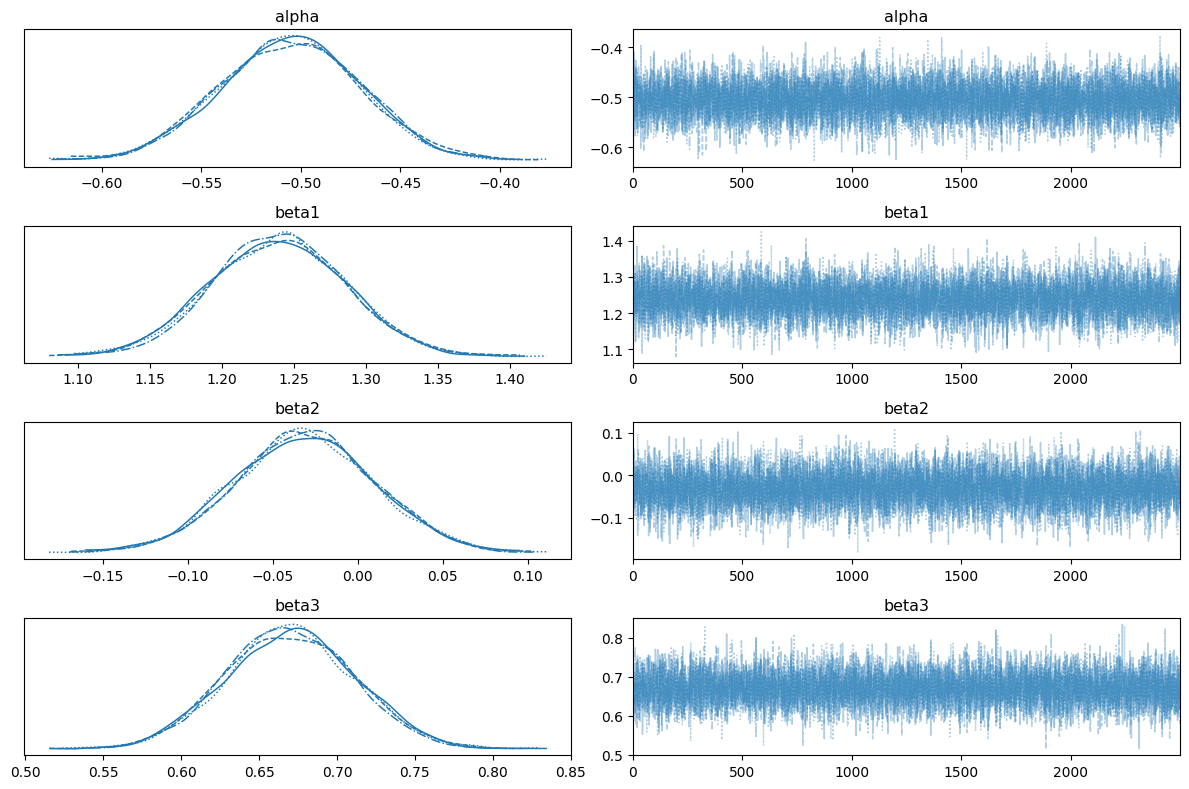

In [14]:
_ = az.plot_trace(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])
plt.tight_layout()

In [15]:
results = fit.draws_pd()

In [16]:
results.head()

,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,y_hat_ex[1758],y_hat_ex[1759],y_hat_ex[1760],y_hat_ex[1761],y_hat_ex[1762],y_hat_ex[1763],y_hat_ex[1764],y_hat_ex[1765],y_hat_ex[1766],y_hat_ex[1767]
0,1.0,1.0,1.0,-2808.4468,0.985935,0.674279,2.0,7.0,0.0,2809.9975,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,1.0,2.0,2.0,-2807.0037,0.949181,0.674279,3.0,7.0,0.0,2810.8296,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.0,3.0,3.0,-2806.8142,0.976246,0.674279,2.0,7.0,0.0,2808.2847,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,4.0,4.0,-2808.0107,0.908254,0.674279,2.0,3.0,0.0,2808.8199,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
4,1.0,5.0,5.0,-2810.7831,0.833389,0.674279,2.0,3.0,0.0,2811.3470,...,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0


# Problem 4

In [40]:
def match_cols_with_name(name: str, first_n_rows: int | None = None):
    cols = [c for c in results.columns if c.startswith(f"{name}[") or c == name]
    if len(cols) == 0:
        raise ValueError('Invalid selection')
    df = results[cols]
    if first_n_rows is not None:
        df = df.iloc[:first_n_rows]
    return df

In [54]:
p_ex_draws = match_cols_with_name('p_ex').to_numpy()

y_ex = np.asarray(split_data_dict["y_ex"], dtype=int)
p_ex_mean = p_ex_draws.mean(axis=0)
brier_score = np.mean((p_ex_mean - y_ex) ** 2)

# 0.5 threshold
y_pred = (p_ex_mean >= 0.5).astype(int)
accuracy = np.mean(y_pred == y_ex)

# baseline
baseline_class = int(np.bincount(split_data_dict["y"]).argmax())
baseline_pred = np.full_like(y_ex, baseline_class)
baseline_brier = np.mean((baseline_pred - y_ex) ** 2)

# posterior
brier_draws = np.mean((p_ex_draws - y_ex[np.newaxis, :]) ** 2, axis=1)

print(f"Brier Score: {brier_score:.4f}")
print(f"Baseline Score: {baseline_brier:.4f}")

print('\nPosterior metric summaries:')
print(f"Brier mean = {brier_draws.mean():.4f}, 95% = [{np.quantile(brier_draws, 0.025):.4f}, {np.quantile(brier_draws, 0.975):.4f}]")

Brier Score: 0.1862
Baseline Score: 0.4329

Posterior metric summaries:
Brier mean = 0.1863, 95% = [0.1845, 0.1883]


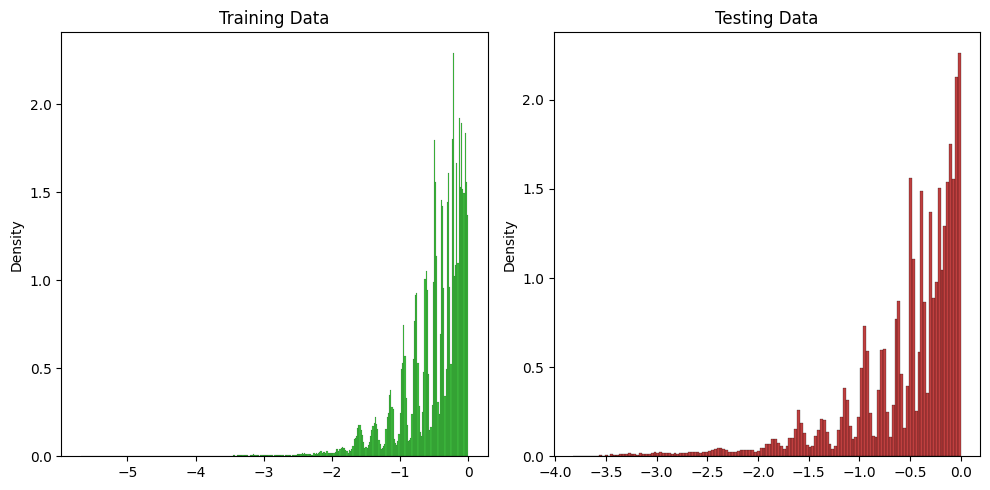

In [52]:
# Marginal check
# sns.histplot(data.shar, color='maroon', stat='density')
# offset the columns when indexing to get alpha, beta1, beta2, beta3, and preds[1...7267]

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot on the first subplot
sns.histplot(match_cols_with_name('preds', first_n_rows=50).values.flatten(), stat='density', color='#00AA00', ax=axes[0])

axes[0].set_title("Training Data")

# Plot on the second subplot
sns.histplot(match_cols_with_name('preds_ex', first_n_rows=50).values.flatten(), stat='density', color='#AA0000', ax=axes[1])
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

In [36]:
fit.summary().head(n=5)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-2807.120000,0.019824,1.424850,1.216840,-2809.880000,-2806.790000,-2805.460000,5243.82,6526.51,106.372,1.000250
alpha,-0.505428,0.000353,0.034128,0.033939,-0.560776,-0.505260,-0.449010,9382.07,7683.60,190.317,0.999893
beta1,1.239290,0.000495,0.047206,0.047463,1.162610,1.239640,1.317320,9120.35,7449.89,185.008,1.000150
beta2,-0.031583,0.000416,0.040633,0.040094,-0.099870,-0.031248,0.035373,9565.35,6894.61,194.035,1.000670
beta3,0.670172,0.000415,0.041487,0.041717,0.603405,0.669692,0.738635,9992.60,7182.98,202.702,1.001170


In [47]:
az.summary(fit, var_names=['alpha', 'beta1', 'beta2', 'beta3'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.505,0.034,-0.568,-0.440,0.0,0.0,9382.0,7684.0,1.0
beta1,1.239,0.047,1.153,1.330,0.0,0.0,9120.0,7450.0,1.0
beta2,-0.032,0.041,-0.109,0.043,0.0,0.0,9565.0,6895.0,1.0
beta3,0.670,0.041,0.591,0.745,0.0,0.0,9993.0,7183.0,1.0


In [51]:
dims = {"y": ["time"], "x1": ["time"], "x2": ["time"], "x3": ["time"], "preds": ["time"], "y_hat": ["time"]}
idata_kwargs = {
    "posterior_predictive": ["y_hat"],
    "log_likelihood": ["preds"],
    "dims": dims,
}
idata = az.from_cmdstanpy(
    posterior=fit, observed_data={"y": data.dec}, constant_data={"x1": data.attr, "x2": data.sinc, "x3": data.shar}, **idata_kwargs
)

In [55]:
class LinearRegressionWrapper(az.CmdStanPySamplingWrapper):
    def sel_observations(self, idx):
        x1data = self.idata_orig.constant_data.x1.values
        x2data = self.idata_orig.constant_data.x2.values
        x3data = self.idata_orig.constant_data.x3.values
        ydata = self.idata_orig.observed_data.y.values
        mask = np.full_like(x1data, True, dtype=bool)
        mask[idx] = False
        N_obs = len(mask)
        N_ex = np.sum(~mask)
        observations = {
            "N": N_obs - N_ex,
            "x1": x1data[mask],
            "x2": x2data[mask],
            "x3": x3data[mask],                        
            "y": ydata[mask],
            "N_ex": N_ex,
            "x1_ex": x1data[~mask],
            "x2_ex": x2data[~mask],
            "x3_ex": x3data[~mask],
            "y_ex": ydata[~mask],
        }
        print(f'{observations=}')
        return observations, "preds_ex"

In [52]:
loo_orig = az.loo(idata, pointwise=True, var_name="preds")
loo_orig

Computed from 10000 posterior samples and 5500 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2809.22    38.27
p_loo        4.27        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5500  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [53]:
loo_orig.pareto_k[[13, 42, 56, 73]] = np.array([0.8, 1.2, 2.6, 3.1])

In [56]:
idata_kwargs["log_likelihood"] = ["preds", "preds_ex"]
cmdstanpy_wrapper = LinearRegressionWrapper(
    model=model,
    idata_orig=idata,
    data_file="linreg_ex_data.json",
    sample_kwargs={"iter_sampling": 2500, "chains": 4},
    idata_kwargs=idata_kwargs,
)

In [57]:
loo_relooed = az.reloo(cmdstanpy_wrapper, loo_orig=loo_orig)

/home/amaan/micromamba/envs/stan/lib/python3.14/site-packages/arviz/stats/stats_refitting.py:100: UserWarning: reloo is an experimental and untested feature
  warnings.warn("reloo is an experimental and untested feature", UserWarning)
15:52:27 - cmdstanpy - INFO - CmdStan start processing


observations={'N': np.int64(7266), 'x1': array([-0.09871572, -0.61170709,  0.41427565, ..., -2.1506812 ,
       -1.12469846, -1.63768983], shape=(7266,)), 'x2': array([ 1.0489125 ,  0.47536493, -0.67173019, ..., -0.09818263,
       -0.67173019, -0.09818263], shape=(7266,)), 'x3': array([-0.21869869,  0.70975664,  1.1739843 , ...,  1.1739843 ,
       -0.21869869, -2.07560936], shape=(7266,)), 'y': array([1, 1, 1, ..., 0, 0, 0], shape=(7266,)), 'N_ex': np.int64(1), 'x1_ex': array([0.41427565]), 'x2_ex': array([0.47536493]), 'x3_ex': array([0.24552897]), 'y_ex': array([1])}
observations={'N': np.int64(7266), 'x1': array([-0.09871572,  0.41427565, -0.61170709, ..., -2.1506812 ,
       -1.12469846, -1.63768983], shape=(7266,)), 'x2': array([ 1.0489125 ,  0.47536493,  0.47536493, ..., -0.09818263,
       -0.67173019, -0.09818263], shape=(7266,)), 'x3': array([-0.21869869,  0.24552897,  0.70975664, ...,  1.1739843 ,
       -0.21869869, -2.07560936], shape=(7266,)), 'y': array([1, 1, 1, ..., 0

chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]







chain 1:   3%|▎         | 100/3500 [00:00<00:09, 345.59it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:00<00:09, 336.71it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [00:00<00:08, 361.74it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:01<00:07, 388.04it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:01<00:07, 393.77it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:01<00:07, 410.96it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:01<00:06, 437.70it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:01<00:05, 453.71it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:02<00:05, 469.59it/s, (Warmup)]





chain 1:  29%|██▊       | 1000/3500 [00:02<00:05, 451.65it/s, (Sampling)]


chain 1:  31%|███▏      | 1100/3500 [00:02<00:07, 307.09it/s, (Sampling)]

chain 1:  34%|███▍      | 1200/3500 [00:03<00:09, 251.11it/s, (Sampling)]


chain 1:  37%|███▋      | 1300/3500 [00:04<00:09, 221.72it/s, (Sampling)]


chain 1:  40%|████      | 1400/350


15:52:45 - cmdstanpy - INFO - CmdStan done processing.


...

15:53:26 - cmdstanpy - INFO - CmdStan start processing


observations={'N': np.int64(7266), 'x1': array([-0.09871572,  0.41427565, -0.61170709, ..., -2.1506812 ,
       -1.12469846, -1.63768983], shape=(7266,)), 'x2': array([ 1.0489125 ,  0.47536493,  0.47536493, ..., -0.09818263,
       -0.67173019, -0.09818263], shape=(7266,)), 'x3': array([-0.21869869,  0.24552897,  0.70975664, ...,  1.1739843 ,
       -0.21869869, -2.07560936], shape=(7266,)), 'y': array([1, 1, 1, ..., 0, 0, 0], shape=(7266,)), 'N_ex': np.int64(1), 'x1_ex': array([0.92726702]), 'x2_ex': array([0.47536493]), 'x3_ex': array([-0.68292636]), 'y_ex': array([1])}


chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]




chain 1:   3%|▎         | 100/3500 [00:00<00:08, 380.09it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:00<00:09, 344.63it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:01<00:08, 385.83it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:01<00:07, 392.11it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:01<00:07, 410.19it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:01<00:06, 434.56it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:01<00:06, 449.83it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:02<00:05, 468.65it/s, (Warmup)]


chain 1:  29%|██▊       | 1000/3500 [00:02<00:05, 457.21it/s, (Sampling)]





chain 1:  31%|███▏      | 1100/3500 [00:02<00:07, 302.64it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [00:03<00:09, 243.23it/s, (Sampling)]


chain 1:  37%|███▋      | 1300/3500 [00:04<00:10, 215.38it/s, (Sampling)]




chain 1:  43%|████▎     | 1500/3500 [00:05<


15:53:35 - cmdstanpy - INFO - CmdStan done processing.


RuntimeError: Error during sampling:

Command and output files:
RunSet: chains=4, chain_ids=[1, 2, 3, 4], num_processes=4
 cmd (chain 1):
	['/ram/COGS4210/HW4/models/hw4_model_new', 'id=1', 'random', 'seed=69097', 'data', 'file=linreg_ex_data.json', 'output', 'file=/tmp/tmpx04mznk7/hw4_model_newfepo1m8l/hw4_model_new-20260414155326_1.csv', 'method=sample', 'num_samples=2500', 'algorithm=hmc', 'adapt', 'engaged=1']
 retcodes=[1, 1, 1, 1]
 per-chain output files (showing chain 1 only):
 csv_file:
	/tmp/tmpx04mznk7/hw4_model_newfepo1m8l/hw4_model_new-20260414155326_1.csv
 console_msgs (if any):
	/tmp/tmpx04mznk7/hw4_model_newfepo1m8l/hw4_model_new-20260414155326_0-stdout.txt
Consider re-running with show_console=True if the above output is unclear!

In [48]:
loo_relooed

NameError: name 'loo_relooed' is not defined

In [27]:
loo_orig

Computed from 10000 posterior samples and 5500 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2809.27    38.27
p_loo        4.32        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5496   99.9%
   (0.70, 1]   (bad)         1    0.0%
   (1, Inf)   (very bad)    3    0.1%